In [208]:
import pandas as pd
from pathlib import Path

test = "1"
parameter = "translation_z"
scene = "empty"
camera = "camera1"
csv_path = Path(f"Output/{scene}/{parameter}/{test}/{camera}_{parameter}_sweep.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

df = pd.read_csv(csv_path)

required_columns = {f"{parameter}", "loss", "analytic_grad", "fd_grad"}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

df.head()

,iter,translation_z,loss,analytic_grad,fd_grad,fd_kind,fd_epsilon
0,0,-2.000000,0.008429,0.004992,0.004963,0,0.001
1,1,-1.866667,0.009368,0.009178,0.009123,0,0.001
2,2,-1.733333,0.010804,0.012075,0.011999,0,0.001
3,3,-1.600000,0.012422,0.011778,0.011680,0,0.001
4,4,-1.466667,0.013783,0.008496,0.008375,0,0.001


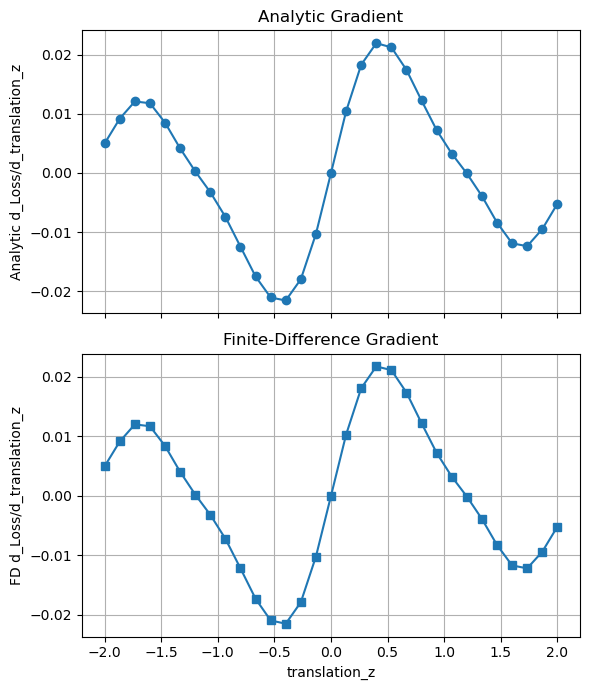

PosixPath('Output/empty/translation_z/1/camera1_translation_z_sweep_grad_subplots.png')

In [209]:
import matplotlib.pyplot as plt

NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 7), sharex=True)

# --- Top: Analytic ---
axes[0].plot(df[f"{parameter}"], df["analytic_grad"], marker="o")
axes[0].set_ylabel(f"Analytic d_Loss/d_{parameter}")
axes[0].set_title("Analytic Gradient")
axes[0].grid(True)

# --- Bottom: Finite Difference ---
axes[1].plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s")
axes[1].set_xlabel(f"{parameter}")
axes[1].set_ylabel(f"FD d_Loss/d_{parameter}")
axes[1].set_title("Finite-Difference Gradient")
axes[1].grid(True)

output_png = csv_path.with_name(csv_path.stem + "_grad_subplots.png")
plt.tight_layout()
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

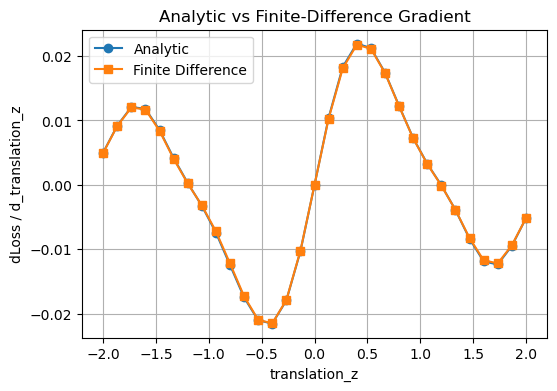

PosixPath('Output/empty/translation_z/1/camera1_translation_z_sweep_grad_compare.png')

In [210]:
NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

plt.figure(figsize=(6, 4))

plt.plot(df[f"{parameter}"], df["analytic_grad"], marker="o", label="Analytic")
plt.plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s", label="Finite Difference")

plt.xlabel(f"{parameter}")
plt.ylabel(f"dLoss / d_{parameter}")
plt.title("Analytic vs Finite-Difference Gradient")
plt.grid(True)
plt.legend()

output_png = csv_path.with_name(csv_path.stem + "_grad_compare.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

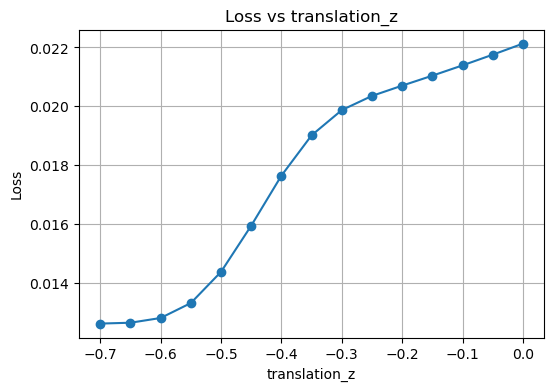

PosixPath('Output/empty/translation_z/0/camera1_translation_z_sweep_loss.png')

In [168]:
plt.figure(figsize=(6, 4))
plt.plot(df[f"{parameter}"], df["loss"], marker="o")
plt.xlabel(f"{parameter}")
plt.ylabel("Loss")
plt.title(f"Loss vs {parameter}")
plt.grid(True)

output_png = csv_path.with_name(csv_path.stem + "_loss.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

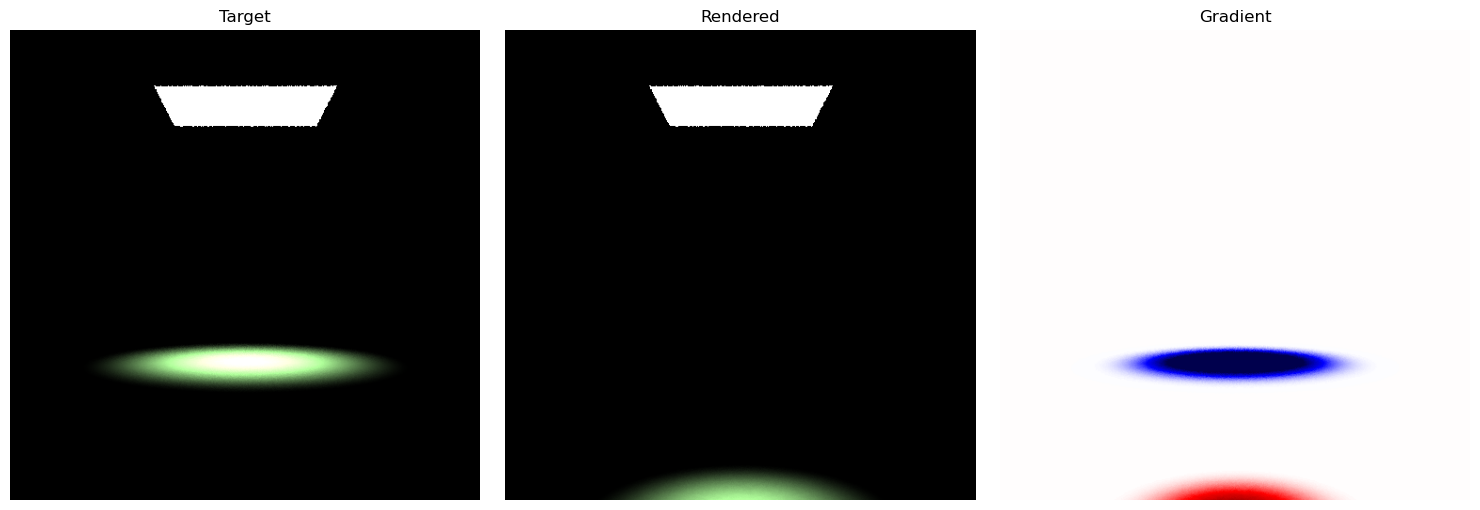

In [169]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Paths
iteration = 3
target_image = Path(f"Output/{scene}/{parameter}/{camera}_target.png")
rendered_test = Path(f"Output/{scene}/{parameter}/{test}/rendered/{iteration}_{camera}.png")
grad_image = Path(f"Output/{scene}/{parameter}/{test}/grad/{iteration}_{camera}.png")



# Load images
img_target = Image.open(target_image)
img_rendered = Image.open(rendered_test)
img_grad = Image.open(grad_image)

# Plot side by side (3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_target)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(img_rendered)
axes[1].set_title("Rendered")
axes[1].axis("off")

axes[2].imshow(img_grad)
axes[2].set_title("Gradient")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [118]:
print(df["analytic_grad"])
print(df[NUMERICAL_COLUMN])


0     0.000000
1     0.000000
2     0.000000
3    -0.000890
4    -0.002080
5    -0.002492
6    -0.002361
7    -0.001883
8    -0.001251
9    -0.000667
10   -0.000170
11    0.000034
12    0.000008
13   -0.000017
14    0.000044
15    0.000177
16    0.000338
17    0.000505
18    0.000626
19    0.000736
20    0.000764
21    0.000812
22    0.000772
23    0.000757
24    0.000686
25    0.000653
26    0.000618
27    0.000601
28    0.000582
29    0.000553
30    0.000458
Name: analytic_grad, dtype: float64
0     0.000000
1     0.000000
2     0.000000
3    -0.000502
4    -0.001025
5    -0.001323
6    -0.001220
7    -0.001005
8    -0.000727
9    -0.000442
10   -0.000166
11   -0.000038
12   -0.000007
13   -0.000009
14    0.000019
15    0.000078
16    0.000160
17    0.000225
18    0.000297
19    0.000345
20    0.000386
21    0.000383
22    0.000391
23    0.000392
24    0.000329
25    0.000335
26    0.000308
27    0.000278
28    0.000243
29    0.000228
30    0.000202
Name: fd_grad, dtype: float64
